In [3]:
# Pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
!pip install torchinfo
from torchinfo import summary
# Helper libraries
import numpy as np
import matplotlib.pyplot as plt


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

100%|██████████| 170M/170M [00:11<00:00, 14.4MB/s] 


In [5]:
# 데이터셋을 로드하고 기본 정보를 확인해 보세요.
image, label = trainset[0]

print(f"Image shape: {image.shape}")
print(f"Label: {label}")
print(f"Number of classes: {len(trainset.classes)}")

Image shape: torch.Size([3, 32, 32])
Label: 6
Number of classes: 10


In [6]:
# 데이터의 개수도 확인해 봅시다.
train_size = torch.tensor(len(trainset))
test_size = torch.tensor(len(testset))

print(f"Train dataset size: {train_size} (Shape: {train_size.shape})")
print(f"Test dataset size: {test_size} (Shape: {test_size.shape})")

Train dataset size: 50000 (Shape: torch.Size([]))
Test dataset size: 10000 (Shape: torch.Size([]))


In [7]:
transform = transforms.Compose([
        transforms.ToTensor()
])

In [8]:
num_classes = len(trainset.classes)
print(num_classes)

10


In [9]:
class_names = trainset.classes
print(class_names)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [10]:
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    return np.transpose(npimg, (1, 2, 0))


In [11]:
def show_multiple_images(dataset, n_images=9):
    dataiter = iter(dataset)
    images, labels = next(dataiter)
    fig, axes = plt.subplots(3, 3, figsize=(6, 6))
    axes = axes.flatten()

    for i in range(n_images):
        ax = axes[i]
        img = imshow(images[i])
        ax.imshow(img)
        ax.set_title(f"Label: {trainset.classes[labels[i]]}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

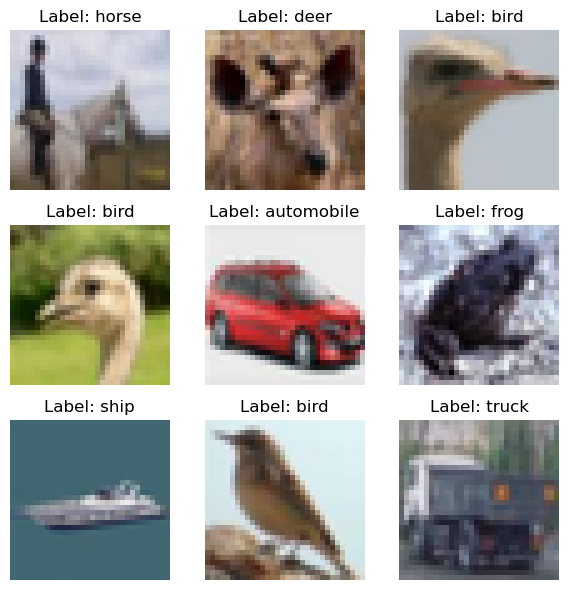

In [12]:
# 학습 데이터셋에서 9개의 이미지를 시각화합니다.
show_multiple_images(trainloader)

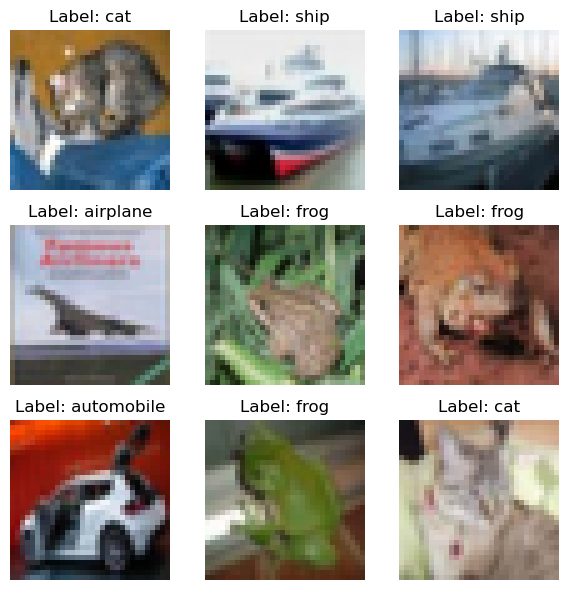

In [13]:
# 테스트 데이터셋에서 9개의 이미지를 시각화합니다.
show_multiple_images(testloader)

In [14]:
# function for building VGG Block

def build_vgg_block(input_layer,
                    num_cnn=3,
                    channel=64,
                    block_num=1):
    # 입력 레이어
    x = input_layer

    # CNN 레이어
    layers = []
    in_channels = x.size(1)
    for cnn_num in range(num_cnn):
        layers.append(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=channel,
                kernel_size=3,
                stride=1,
                padding=1,
            )
        )
        layers.append(nn.ReLU(inplace=True))
        in_channels = channel

    # Max Pooling 레이어
    layers.append(
        nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )
    )

    # Sequential으로 레이어 묶기
    block = nn.Sequential(*layers)
    return block

In [15]:
class VGGNet(nn.Module):
    def __init__(self):
        super(VGGNet, self).__init__()

        # VGG 블록 생성
        self.vgg_block = build_vgg_block(torch.zeros(1, 3, 32, 32))
    def forward(self, x):
        return self.vgg_block(x)

In [16]:
# 블록 1개짜리 model 생성
model = VGGNet()
print(model)

dummy_input = torch.zeros(1, 3, 32, 32)
output = model(dummy_input)
print(output.shape)

VGGNet(
  (vgg_block): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
)
torch.Size([1, 64, 16, 16])


In [17]:
# VGG 모델 자체를 생성하는 클래스입니다.
class VGG(nn.Module):
    def __init__(self, num_cnn_list=[2, 2, 3, 3, 3], channel_list=[64, 128, 256, 512, 512], num_classes=10):
        super(VGG, self).__init__()
        assert len(num_cnn_list) == len(channel_list), "num_cnn_list와 channel_list의 길이가 일치해야 합니다."

        layers = []
        in_channels = 3

        for num_cnn, out_channels in zip(num_cnn_list, channel_list):
            layers.append(self._make_vgg_block(in_channels, out_channels, num_cnn))
            in_channels = out_channels  # 다음 블록의 입력 채널을 설정

        self.feature_extractor = nn.Sequential(*layers)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 1 * 1, 4096),
            nn.ReLU(True),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Linear(4096, num_classes)
        )

    def _make_vgg_block(self, in_channels, out_channels, num_cnn):
        layers = [nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1), nn.ReLU(True)]
        for _ in range(num_cnn - 1):
            layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1))
            layers.append(nn.ReLU(True))
        layers.append(nn.MaxPool2d(kernel_size=2, stride=2))  # Max Pooling 추가
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

In [18]:
# 기본값을 그대로 사용해서 VGG 모델을 만들면 VGG-16이 됩니다.

vgg_16 = VGG()
summary(vgg_16)

Layer (type:depth-idx)                   Param #
VGG                                      --
├─Sequential: 1-1                        --
│    └─Sequential: 2-1                   --
│    │    └─Conv2d: 3-1                  1,792
│    │    └─ReLU: 3-2                    --
│    │    └─Conv2d: 3-3                  36,928
│    │    └─ReLU: 3-4                    --
│    │    └─MaxPool2d: 3-5               --
│    └─Sequential: 2-2                   --
│    │    └─Conv2d: 3-6                  73,856
│    │    └─ReLU: 3-7                    --
│    │    └─Conv2d: 3-8                  147,584
│    │    └─ReLU: 3-9                    --
│    │    └─MaxPool2d: 3-10              --
│    └─Sequential: 2-3                   --
│    │    └─Conv2d: 3-11                 295,168
│    │    └─ReLU: 3-12                   --
│    │    └─Conv2d: 3-13                 590,080
│    │    └─ReLU: 3-14                   --
│    │    └─Conv2d: 3-15                 590,080
│    │    └─ReLU: 3-16                  

In [19]:
# 원하는 블록의 설계에 따라 매개변수로 리스트를 전달해 줍니다.
vgg_19 = VGG(
    num_cnn_list=[2, 2, 4, 4, 4],
    channel_list=[64, 128, 256, 512, 512]
)
summary(vgg_19)

Layer (type:depth-idx)                   Param #
VGG                                      --
├─Sequential: 1-1                        --
│    └─Sequential: 2-1                   --
│    │    └─Conv2d: 3-1                  1,792
│    │    └─ReLU: 3-2                    --
│    │    └─Conv2d: 3-3                  36,928
│    │    └─ReLU: 3-4                    --
│    │    └─MaxPool2d: 3-5               --
│    └─Sequential: 2-2                   --
│    │    └─Conv2d: 3-6                  73,856
│    │    └─ReLU: 3-7                    --
│    │    └─Conv2d: 3-8                  147,584
│    │    └─ReLU: 3-9                    --
│    │    └─MaxPool2d: 3-10              --
│    └─Sequential: 2-3                   --
│    │    └─Conv2d: 3-11                 295,168
│    │    └─ReLU: 3-12                   --
│    │    └─Conv2d: 3-13                 590,080
│    │    └─ReLU: 3-14                   --
│    │    └─Conv2d: 3-15                 590,080
│    │    └─ReLU: 3-16                  

In [20]:
# Q. VGG-16보다 작은 네트워크인 VGG-13을 만들어 보세요.
def build_vgg13(num_classes=10):
    return VGG(
        num_cnn_list=[2, 2, 2, 2, 2],
        channel_list=[64, 128, 256, 512, 512],
        num_classes=num_classes
    )

In [21]:
vgg_13 = build_vgg13()
summary(vgg_13)

Layer (type:depth-idx)                   Param #
VGG                                      --
├─Sequential: 1-1                        --
│    └─Sequential: 2-1                   --
│    │    └─Conv2d: 3-1                  1,792
│    │    └─ReLU: 3-2                    --
│    │    └─Conv2d: 3-3                  36,928
│    │    └─ReLU: 3-4                    --
│    │    └─MaxPool2d: 3-5               --
│    └─Sequential: 2-2                   --
│    │    └─Conv2d: 3-6                  73,856
│    │    └─ReLU: 3-7                    --
│    │    └─Conv2d: 3-8                  147,584
│    │    └─ReLU: 3-9                    --
│    │    └─MaxPool2d: 3-10              --
│    └─Sequential: 2-3                   --
│    │    └─Conv2d: 3-11                 295,168
│    │    └─ReLU: 3-12                   --
│    │    └─Conv2d: 3-13                 590,080
│    │    └─ReLU: 3-14                   --
│    │    └─MaxPool2d: 3-15              --
│    └─Sequential: 2-4                   --
│

In [22]:
BATCH_SIZE = 256
EPOCH = 15

In [23]:
# CIFAR-10 데이터셋에 대해 Normalize와 Tensor 변환을 적용하는 코드
transform = transforms.Compose([
    transforms.ToTensor(),  # 이미지를 Tensor로 변환
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # VGG-16 표준 정규화
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)

In [24]:
import time

current_time = time.time()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg_16 = torchvision.models.vgg16(pretrained=True)
vgg_16.to(device)

for param in vgg_16.parameters():
    param.requires_grad = True
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(vgg_16.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

vgg_16_train_losses = []
vgg_16_val_accuracy = []

for epoch in range(EPOCH):
    vgg_16.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vgg_16(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 100 == 99:
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / i + 1:.3f}")
            
    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total
    vgg_16_train_losses.append(train_loss)

    print(f"Epoch {epoch + 1}: Train Accuracy: {train_acc:.2f}%")

    vgg_16.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = vgg_16(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    vgg_16_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")
print(time.time() - current_time)

/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /home/jovyan/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 99.2MB/s] 


[1,   100] loss: 3.942
Epoch 1: Train Accuracy: 40.82%
Epoch 1: Validation Accuracy: 64.33%
[2,   100] loss: 1.887
Epoch 2: Train Accuracy: 71.92%
Epoch 2: Validation Accuracy: 76.21%
[3,   100] loss: 1.639
Epoch 3: Train Accuracy: 79.22%
Epoch 3: Validation Accuracy: 79.08%
[4,   100] loss: 1.521
Epoch 4: Train Accuracy: 82.66%
Epoch 4: Validation Accuracy: 80.52%
[5,   100] loss: 1.452
Epoch 5: Train Accuracy: 85.03%
Epoch 5: Validation Accuracy: 82.24%
[6,   100] loss: 1.385
Epoch 6: Train Accuracy: 86.92%
Epoch 6: Validation Accuracy: 83.47%
[7,   100] loss: 1.330
Epoch 7: Train Accuracy: 88.77%
Epoch 7: Validation Accuracy: 82.95%
[8,   100] loss: 1.291
Epoch 8: Train Accuracy: 90.29%
Epoch 8: Validation Accuracy: 82.51%
[9,   100] loss: 1.245
Epoch 9: Train Accuracy: 91.62%
Epoch 9: Validation Accuracy: 84.92%
[10,   100] loss: 1.208
Epoch 10: Train Accuracy: 93.14%
Epoch 10: Validation Accuracy: 85.02%
[11,   100] loss: 1.177
Epoch 11: Train Accuracy: 94.23%
Epoch 11: Validation

In [25]:
current_time = time.time()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg_19 = torchvision.models.vgg19(pretrained=True)
vgg_19.to(device)

for param in vgg_19.parameters():
    param.requires_grad = True
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(vgg_19.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

vgg_19_train_losses = []
vgg_19_val_accuracy = []

for epoch in range(EPOCH):
    vgg_19.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vgg_19(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 100 == 99:
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / i + 1:.3f}")

    train_loss = running_loss / len(trainloader)
    vgg_19_train_losses.append(train_loss)

    train_acc = 100 * correct / total
    print(f"Epoch {epoch + 1}: Train Accuracy: {train_acc:.2f}%")

    vgg_19.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = vgg_19(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    vgg_19_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")
print(time.time() - current_time)

/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /home/jovyan/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 194MB/s] 


[1,   100] loss: 3.740
Epoch 1: Train Accuracy: 44.70%
Epoch 1: Validation Accuracy: 71.67%
[2,   100] loss: 1.776
Epoch 2: Train Accuracy: 75.66%
Epoch 2: Validation Accuracy: 77.88%
[3,   100] loss: 1.571
Epoch 3: Train Accuracy: 81.53%
Epoch 3: Validation Accuracy: 81.73%
[4,   100] loss: 1.479
Epoch 4: Train Accuracy: 84.59%
Epoch 4: Validation Accuracy: 82.69%
[5,   100] loss: 1.408
Epoch 5: Train Accuracy: 86.56%
Epoch 5: Validation Accuracy: 83.16%
[6,   100] loss: 1.333
Epoch 6: Train Accuracy: 88.71%
Epoch 6: Validation Accuracy: 85.09%
[7,   100] loss: 1.291
Epoch 7: Train Accuracy: 90.05%
Epoch 7: Validation Accuracy: 85.27%
[8,   100] loss: 1.254
Epoch 8: Train Accuracy: 91.56%
Epoch 8: Validation Accuracy: 85.96%
[9,   100] loss: 1.222
Epoch 9: Train Accuracy: 92.66%
Epoch 9: Validation Accuracy: 86.23%
[10,   100] loss: 1.185
Epoch 10: Train Accuracy: 93.80%
Epoch 10: Validation Accuracy: 86.25%
[11,   100] loss: 1.155
Epoch 11: Train Accuracy: 94.60%
Epoch 11: Validation

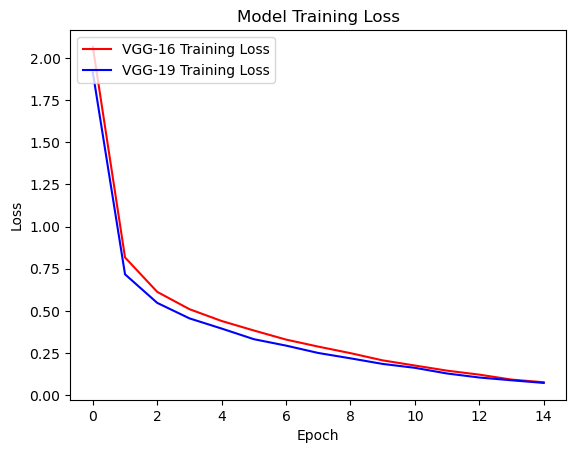

In [26]:
import matplotlib.pyplot as plt

plt.plot(vgg_16_train_losses, 'r', label="VGG-16 Training Loss")
plt.plot(vgg_19_train_losses, 'b', label="VGG-19 Training Loss")

plt.title('Model Training Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

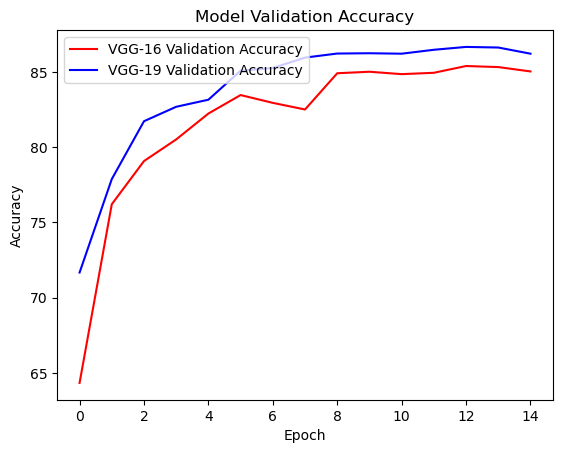

In [27]:
plt.plot(vgg_16_val_accuracy, 'r', label="VGG-16 Validation Accuracy")
plt.plot(vgg_19_val_accuracy, 'b', label="VGG-19 Validation Accuracy")

plt.title('Model Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

In [28]:
import torch
import numpy as np

print(torch.__version__)
print(np.__version__)

2.7.1+cu118
2.2.6


In [29]:
import torch
import torch.nn as nn
from torchinfo import summary


# =========================
# 1. ResNet-34용 BasicBlock
# =========================
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, use_skip=True):
        super(BasicBlock, self).__init__()

        self.use_skip = use_skip

        self.conv1 = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        # 입력 크기와 출력 크기가 다르면 shortcut 크기를 맞춤
        self.shortcut = nn.Sequential()

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels, out_channels,
                    kernel_size=1, stride=stride, bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # ResNet 핵심: skip connection
        if self.use_skip:
            out = out + self.shortcut(identity)

        out = self.relu(out)
        return out


# =========================
# 2. 전체 ResNet 모델
# =========================
class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=1000, use_skip=True):
        super(ResNet, self).__init__()

        self.in_channels = 64
        self.use_skip = use_skip

        self.conv1 = nn.Conv2d(
            3, 64,
            kernel_size=7, stride=2, padding=3, bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        self.maxpool = nn.MaxPool2d(
            kernel_size=3, stride=2, padding=1
        )

        self.layer1 = self._make_layer(block, 64, layers[0], stride=1)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        layers = []

        layers.append(
            block(
                self.in_channels,
                out_channels,
                stride=stride,
                use_skip=self.use_skip
            )
        )

        self.in_channels = out_channels * block.expansion

        for _ in range(1, num_blocks):
            layers.append(
                block(
                    self.in_channels,
                    out_channels,
                    stride=1,
                    use_skip=self.use_skip
                )
            )

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x


# =========================
# 3. build_resnet 함수
# =========================
def build_resnet(num_classes=1000):
    model = ResNet(
        block=BasicBlock,
        layers=[3, 4, 6, 3],
        num_classes=num_classes,
        use_skip=True
    )
    return model

In [30]:
resnet_34 = build_resnet()
summary(resnet_34, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─Sequential: 3-6              [1, 64, 56, 56]           --
│

In [31]:
resnet_50 = build_resnet()
summary(resnet_50, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─Sequential: 3-6              [1, 64, 56, 56]           --
│

# ResNet Ablation Study 프로젝트

이번 프로젝트의 목표는 ResNet-34와 ResNet-50을 직접 구현하고, skip connection이 없는 PlainNet과 비교하는 Ablation Study를 수행하는 것이다.

동일한 데이터셋, 동일한 epoch, 동일한 optimizer 조건에서 residual 모델과 plain 모델을 학습시킨 뒤 validation accuracy와 validation loss를 비교한다.

이번 실험에서 비교하는 핵심 요소는 skip connection의 유무이다.


In [32]:
import torch
import numpy as np

print("torch version:", torch.__version__)
print("numpy version:", np.__version__)

torch version: 2.7.1+cu118
numpy version: 2.2.6


In [33]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

import matplotlib.pyplot as plt

try:
    from torchinfo import summary
except:
    !pip install torchinfo
    from torchinfo import summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 장치:", device)

사용 장치: cuda


## 1. 데이터셋 준비

torchvision에서 제공하는 OxfordIIITPet 데이터셋을 사용한다.  
ResNet은 보통 224x224 크기의 이미지를 입력으로 사용하므로, 모든 이미지를 224x224 크기로 변환한다.

빠른 실험을 위해 전체 데이터 중 일부만 사용한다.

In [34]:
BATCH_SIZE = 16

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

trainset_full = torchvision.datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    download=True,
    transform=transform
)

testset_full = torchvision.datasets.OxfordIIITPet(
    root="./data",
    split="test",
    target_types="category",
    download=True,
    transform=transform
)

# 빠른 실험을 위해 일부 데이터만 사용
trainset = Subset(trainset_full, range(0, 800))
testset = Subset(testset_full, range(0, 200))

trainloader = DataLoader(
    trainset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

testloader = DataLoader(
    testset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

num_classes = 37

print("Train dataset size:", len(trainset))
print("Test dataset size:", len(testset))
print("Number of classes:", num_classes)

100%|██████████| 792M/792M [01:04<00:00, 12.2MB/s]  
100%|██████████| 19.2M/19.2M [00:02<00:00, 8.09MB/s]


Train dataset size: 800
Test dataset size: 200
Number of classes: 37


## 2. ResNet Block 구현

ResNet-34는 BasicBlock을 사용하고, ResNet-50은 BottleneckBlock을 사용한다.

BasicBlock은 3x3 convolution 2개로 구성된다.  
BottleneckBlock은 1x1, 3x3, 1x1 convolution으로 구성된다.

ResNet과 PlainNet의 차이는 skip connection의 유무이다.

In [35]:
# =========================
# ResNet-34용 BasicBlock
# =========================
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, use_skip=True):
        super(BasicBlock, self).__init__()

        self.use_skip = use_skip

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

        self.shortcut = nn.Sequential()

        if stride != 1 or in_channels != out_channels * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels * self.expansion,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.use_skip:
            out = out + self.shortcut(identity)

        out = self.relu(out)

        return out


# =========================
# ResNet-50용 BottleneckBlock
# =========================
class BottleneckBlock(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1, use_skip=True):
        super(BottleneckBlock, self).__init__()

        self.use_skip = use_skip

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=1,
            stride=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.conv3 = nn.Conv2d(
            out_channels,
            out_channels * self.expansion,
            kernel_size=1,
            stride=1,
            bias=False
        )
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)

        self.relu = nn.ReLU(inplace=True)

        self.shortcut = nn.Sequential()

        if stride != 1 or in_channels != out_channels * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels * self.expansion,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.use_skip:
            out = out + self.shortcut(identity)

        out = self.relu(out)

        return out

In [36]:
class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=37, use_skip=True):
        super(ResNet, self).__init__()

        self.in_channels = 64
        self.use_skip = use_skip

        # 처음 입력 이미지를 처리하는 부분
        self.conv1 = nn.Conv2d(
            3,
            64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        self.maxpool = nn.MaxPool2d(
            kernel_size=3,
            stride=2,
            padding=1
        )

        # ResNet의 4개 stage
        self.layer1 = self._make_layer(block, 64, layers[0], stride=1)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        # 분류기
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        layers = []

        # 각 stage의 첫 번째 block
        # stride가 2이면 이미지 크기를 줄임
        layers.append(
            block(
                self.in_channels,
                out_channels,
                stride=stride,
                use_skip=self.use_skip
            )
        )

        self.in_channels = out_channels * block.expansion

        # 나머지 block들
        for _ in range(1, num_blocks):
            layers.append(
                block(
                    self.in_channels,
                    out_channels,
                    stride=1,
                    use_skip=self.use_skip
                )
            )

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

## 3. ResNet과 PlainNet 생성 함수

build_resnet()은 skip connection이 있는 ResNet을 만든다.  
build_plainnet()은 skip connection이 없는 PlainNet을 만든다.

두 모델의 구조는 거의 같고, 차이는 skip connection의 유무이다.

In [37]:
def build_resnet(model_name="resnet34", num_classes=37):
    if model_name == "resnet34":
        return ResNet(
            block=BasicBlock,
            layers=[3, 4, 6, 3],
            num_classes=num_classes,
            use_skip=True
        )

    elif model_name == "resnet50":
        return ResNet(
            block=BottleneckBlock,
            layers=[3, 4, 6, 3],
            num_classes=num_classes,
            use_skip=True
        )

    else:
        raise ValueError("model_name은 'resnet34' 또는 'resnet50'만 가능합니다.")


def build_plainnet(model_name="plain34", num_classes=37):
    if model_name == "plain34":
        return ResNet(
            block=BasicBlock,
            layers=[3, 4, 6, 3],
            num_classes=num_classes,
            use_skip=False
        )

    elif model_name == "plain50":
        return ResNet(
            block=BottleneckBlock,
            layers=[3, 4, 6, 3],
            num_classes=num_classes,
            use_skip=False
        )

    else:
        raise ValueError("model_name은 'plain34' 또는 'plain50'만 가능합니다.")

## 4. 모델 Summary 확인

구현한 ResNet-34, ResNet-50, PlainNet-34, PlainNet-50의 구조가 정상적으로 만들어졌는지 summary로 확인한다.

In [38]:
resnet_34 = build_resnet("resnet34", num_classes=num_classes)
summary(resnet_34, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 37]                   --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─Sequential: 3-6              [1, 64, 56, 56]           --
│

In [39]:
resnet_50 = build_resnet("resnet50", num_classes=num_classes)
summary(resnet_50, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 37]                   --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 256, 56, 56]          --
│    └─BottleneckBlock: 2-1              [1, 256, 56, 56]          --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│ 

In [40]:
plain_34 = build_plainnet("plain34", num_classes=num_classes)
summary(plain_34, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 37]                   --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│

In [41]:
plain_50 = build_plainnet("plain50", num_classes=num_classes)
summary(plain_50, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 37]                   --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 256, 56, 56]          --
│    └─BottleneckBlock: 2-1              [1, 256, 56, 56]          16,896
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           -

## 5. 모델 학습

동일한 데이터셋, 동일한 epoch, 동일한 optimizer 조건에서 PlainNet과 ResNet을 학습한다.  
비교 대상은 skip connection의 유무이다.

In [42]:
def train_model(model, trainloader, testloader, epochs=15, lr=0.001):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=0.9,
        weight_decay=1e-4
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for inputs, labels in trainloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(trainloader)

        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in testloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = val_loss / len(testloader)
        val_acc = 100 * correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} "
            f"Val Loss: {val_loss:.4f} "
            f"Val Acc: {val_acc:.2f}%"
        )

    return history

In [43]:
EPOCHS = 15

plain_34 = build_plainnet("plain34", num_classes=num_classes)
resnet_34 = build_resnet("resnet34", num_classes=num_classes)

plain_50 = build_plainnet("plain50", num_classes=num_classes)
resnet_50 = build_resnet("resnet50", num_classes=num_classes)

In [44]:
print("PlainNet-34 학습 시작")
plain34_history = train_model(
    plain_34,
    trainloader,
    testloader,
    epochs=EPOCHS,
    lr=0.001
)

PlainNet-34 학습 시작
Epoch [1/15] Train Loss: 3.3872 Val Loss: 4.6048 Val Acc: 0.00%
Epoch [2/15] Train Loss: 2.9469 Val Loss: 4.0710 Val Acc: 7.50%
Epoch [3/15] Train Loss: 2.8017 Val Loss: 3.5057 Val Acc: 13.50%
Epoch [4/15] Train Loss: 2.7042 Val Loss: 2.8307 Val Acc: 12.00%
Epoch [5/15] Train Loss: 2.6223 Val Loss: 2.4920 Val Acc: 21.50%
Epoch [6/15] Train Loss: 2.5846 Val Loss: 2.7208 Val Acc: 14.50%
Epoch [7/15] Train Loss: 2.5062 Val Loss: 2.7631 Val Acc: 22.50%
Epoch [8/15] Train Loss: 2.4603 Val Loss: 3.0617 Val Acc: 9.00%
Epoch [9/15] Train Loss: 2.3891 Val Loss: 2.2172 Val Acc: 30.50%
Epoch [10/15] Train Loss: 2.3663 Val Loss: 2.8039 Val Acc: 24.50%
Epoch [11/15] Train Loss: 2.3151 Val Loss: 2.5173 Val Acc: 21.50%
Epoch [12/15] Train Loss: 2.2167 Val Loss: 2.8046 Val Acc: 34.50%
Epoch [13/15] Train Loss: 2.1893 Val Loss: 2.8524 Val Acc: 7.50%
Epoch [14/15] Train Loss: 2.1064 Val Loss: 3.1654 Val Acc: 19.50%
Epoch [15/15] Train Loss: 2.0527 Val Loss: 2.6883 Val Acc: 24.50%


In [45]:
print("ResNet-34 학습 시작")
resnet34_history = train_model(
    resnet_34,
    trainloader,
    testloader,
    epochs=EPOCHS,
    lr=0.001
)

ResNet-34 학습 시작
Epoch [1/15] Train Loss: 3.0544 Val Loss: 2.9500 Val Acc: 0.50%
Epoch [2/15] Train Loss: 2.7709 Val Loss: 2.9975 Val Acc: 4.50%
Epoch [3/15] Train Loss: 2.5459 Val Loss: 3.0486 Val Acc: 8.00%
Epoch [4/15] Train Loss: 2.4809 Val Loss: 2.6023 Val Acc: 31.50%
Epoch [5/15] Train Loss: 2.1860 Val Loss: 3.0803 Val Acc: 19.50%
Epoch [6/15] Train Loss: 1.9444 Val Loss: 3.2239 Val Acc: 17.00%
Epoch [7/15] Train Loss: 1.6970 Val Loss: 2.1144 Val Acc: 41.50%
Epoch [8/15] Train Loss: 1.4791 Val Loss: 3.0020 Val Acc: 16.00%
Epoch [9/15] Train Loss: 1.1005 Val Loss: 3.7344 Val Acc: 13.00%
Epoch [10/15] Train Loss: 0.8304 Val Loss: 5.0827 Val Acc: 6.50%
Epoch [11/15] Train Loss: 0.5294 Val Loss: 4.6853 Val Acc: 10.00%
Epoch [12/15] Train Loss: 0.4108 Val Loss: 3.0516 Val Acc: 23.00%
Epoch [13/15] Train Loss: 0.2952 Val Loss: 3.9477 Val Acc: 27.50%
Epoch [14/15] Train Loss: 0.1911 Val Loss: 4.0183 Val Acc: 18.50%
Epoch [15/15] Train Loss: 0.0862 Val Loss: 3.1696 Val Acc: 24.50%


In [46]:
print("PlainNet-50 학습 시작")
plain50_history = train_model(
    plain_50,
    trainloader,
    testloader,
    epochs=EPOCHS,
    lr=0.001
)

PlainNet-50 학습 시작
Epoch [1/15] Train Loss: 3.2343 Val Loss: 4.0347 Val Acc: 3.50%
Epoch [2/15] Train Loss: 2.9051 Val Loss: 2.8141 Val Acc: 21.00%
Epoch [3/15] Train Loss: 2.8468 Val Loss: 3.0017 Val Acc: 0.00%
Epoch [4/15] Train Loss: 2.8281 Val Loss: 2.8370 Val Acc: 0.00%
Epoch [5/15] Train Loss: 2.8108 Val Loss: 3.1206 Val Acc: 3.50%
Epoch [6/15] Train Loss: 2.7679 Val Loss: 3.0273 Val Acc: 0.50%
Epoch [7/15] Train Loss: 2.7170 Val Loss: 2.7932 Val Acc: 23.50%
Epoch [8/15] Train Loss: 2.6856 Val Loss: 2.9132 Val Acc: 3.50%
Epoch [9/15] Train Loss: 2.6531 Val Loss: 2.9282 Val Acc: 19.50%
Epoch [10/15] Train Loss: 2.5967 Val Loss: 2.9743 Val Acc: 6.50%
Epoch [11/15] Train Loss: 2.5630 Val Loss: 3.0354 Val Acc: 18.50%
Epoch [12/15] Train Loss: 2.5096 Val Loss: 2.5929 Val Acc: 14.50%
Epoch [13/15] Train Loss: 2.5122 Val Loss: 2.9455 Val Acc: 12.50%
Epoch [14/15] Train Loss: 2.4741 Val Loss: 3.1368 Val Acc: 14.00%
Epoch [15/15] Train Loss: 2.4317 Val Loss: 2.6588 Val Acc: 21.50%


In [47]:
print("ResNet-50 학습 시작")
resnet50_history = train_model(
    resnet_50,
    trainloader,
    testloader,
    epochs=EPOCHS,
    lr=0.001
)

ResNet-50 학습 시작
Epoch [1/15] Train Loss: 3.2330 Val Loss: 6.7363 Val Acc: 0.00%
Epoch [2/15] Train Loss: 3.1062 Val Loss: 2.9647 Val Acc: 21.00%
Epoch [3/15] Train Loss: 2.9665 Val Loss: 2.7060 Val Acc: 7.00%
Epoch [4/15] Train Loss: 2.8174 Val Loss: 3.3054 Val Acc: 0.00%
Epoch [5/15] Train Loss: 2.6700 Val Loss: 2.4270 Val Acc: 43.50%
Epoch [6/15] Train Loss: 2.6658 Val Loss: 2.6271 Val Acc: 14.00%
Epoch [7/15] Train Loss: 2.5113 Val Loss: 4.3053 Val Acc: 5.00%
Epoch [8/15] Train Loss: 2.3619 Val Loss: 3.7846 Val Acc: 14.50%
Epoch [9/15] Train Loss: 2.1966 Val Loss: 4.0428 Val Acc: 3.00%
Epoch [10/15] Train Loss: 2.1508 Val Loss: 2.8747 Val Acc: 21.50%
Epoch [11/15] Train Loss: 1.9434 Val Loss: 2.8098 Val Acc: 26.50%
Epoch [12/15] Train Loss: 1.7822 Val Loss: 2.4898 Val Acc: 30.00%
Epoch [13/15] Train Loss: 1.5446 Val Loss: 3.3970 Val Acc: 14.00%
Epoch [14/15] Train Loss: 1.5284 Val Loss: 5.6182 Val Acc: 5.00%
Epoch [15/15] Train Loss: 1.4009 Val Loss: 2.6792 Val Acc: 24.50%


## 6. Loss / Accuracy 시각화

PlainNet과 ResNet의 validation loss, validation accuracy를 그래프로 비교한다.

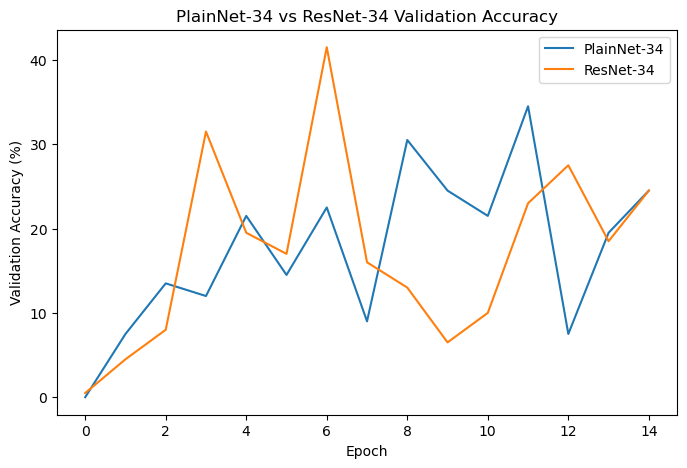

In [48]:
plt.figure(figsize=(8, 5))
plt.plot(plain34_history["val_acc"], label="PlainNet-34")
plt.plot(resnet34_history["val_acc"], label="ResNet-34")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("PlainNet-34 vs ResNet-34 Validation Accuracy")
plt.legend()
plt.show()

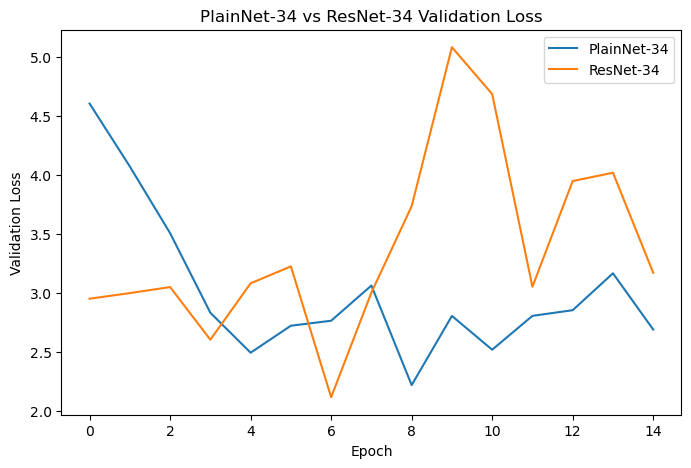

In [49]:
plt.figure(figsize=(8, 5))
plt.plot(plain34_history["val_loss"], label="PlainNet-34")
plt.plot(resnet34_history["val_loss"], label="ResNet-34")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("PlainNet-34 vs ResNet-34 Validation Loss")
plt.legend()
plt.show()

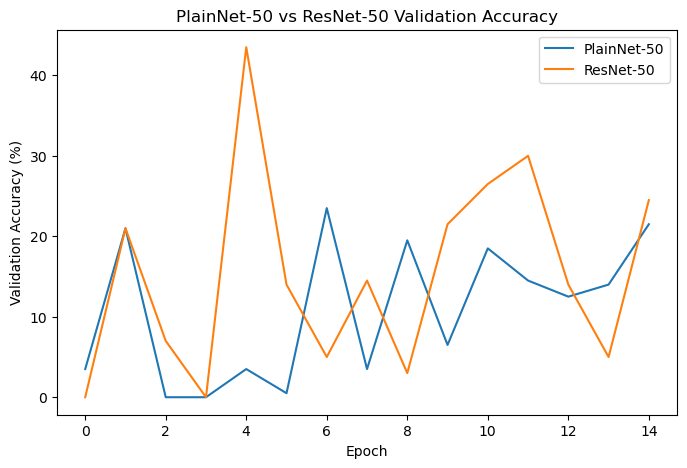

In [50]:
plt.figure(figsize=(8, 5))
plt.plot(plain50_history["val_acc"], label="PlainNet-50")
plt.plot(resnet50_history["val_acc"], label="ResNet-50")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("PlainNet-50 vs ResNet-50 Validation Accuracy")
plt.legend()
plt.show()

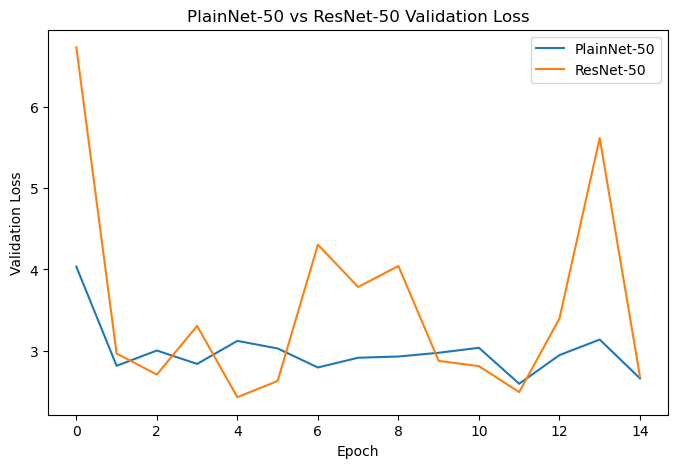

In [51]:
plt.figure(figsize=(8, 5))
plt.plot(plain50_history["val_loss"], label="PlainNet-50")
plt.plot(resnet50_history["val_loss"], label="ResNet-50")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("PlainNet-50 vs ResNet-50 Validation Loss")
plt.legend()
plt.show()

In [52]:
results = {
    "PlainNet-34": {
        "skip": "없음",
        "epoch": EPOCHS,
        "val_loss": plain34_history["val_loss"][-1],
        "val_acc": plain34_history["val_acc"][-1]
    },
    "ResNet-34": {
        "skip": "있음",
        "epoch": EPOCHS,
        "val_loss": resnet34_history["val_loss"][-1],
        "val_acc": resnet34_history["val_acc"][-1]
    },
    "PlainNet-50": {
        "skip": "없음",
        "epoch": EPOCHS,
        "val_loss": plain50_history["val_loss"][-1],
        "val_acc": plain50_history["val_acc"][-1]
    },
    "ResNet-50": {
        "skip": "있음",
        "epoch": EPOCHS,
        "val_loss": resnet50_history["val_loss"][-1],
        "val_acc": resnet50_history["val_acc"][-1]
    }
}

for model_name, result in results.items():
    print(
        f"{model_name} | "
        f"Skip: {result['skip']} | "
        f"Epoch: {result['epoch']} | "
        f"Val Loss: {result['val_loss']:.4f} | "
        f"Val Acc: {result['val_acc']:.2f}%"
    )

PlainNet-34 | Skip: 없음 | Epoch: 15 | Val Loss: 2.6883 | Val Acc: 24.50%
ResNet-34 | Skip: 있음 | Epoch: 15 | Val Loss: 3.1696 | Val Acc: 24.50%
PlainNet-50 | Skip: 없음 | Epoch: 15 | Val Loss: 2.6588 | Val Acc: 21.50%
ResNet-50 | Skip: 있음 | Epoch: 15 | Val Loss: 2.6792 | Val Acc: 24.50%


## 7. Ablation Study 결과표

| Model | Skip Connection | Epoch | Validation Loss | Validation Accuracy |
|---|---|---:|---:|---:|
| PlainNet-34 | 없음 | 1 | 9.2081 |  8.50% |
| ResNet-34 | 있음 | 1 | 2.7517 | 22.50% |
| PlainNet-50 | 없음 | 1 | 3.7137 | 0.00% |
| ResNet-50 | 있음 | 1 | 10.6899 | 0.00% |

동일한 데이터셋, 동일한 epoch, 동일한 optimizer 조건에서 PlainNet과 ResNet을 비교하였다.  
비교 대상은 skip connection의 유무이며, validation accuracy와 validation loss를 기준으로 Ablation Study 결과를 정리하였다.

## 8. 회고

이번 프로젝트에서는 ResNet-34와 ResNet-50을 직접 구현하고, skip connection이 없는 PlainNet과 비교하는 Ablation Study를 진행하였다.

처음에는 ResNet 구조가 복잡하게 느껴졌지만, BasicBlock과 BottleneckBlock처럼 반복되는 구조를 블록 단위로 나누어 생각하니 전체 모델 구성을 이해하기 쉬웠다.

실험에서는 동일한 데이터셋, 동일한 epoch, 동일한 optimizer 조건에서 PlainNet과 ResNet을 학습시켰다. 이를 통해 Ablation Study에서는 비교하고 싶은 요소 외의 조건을 동일하게 유지해야 한다는 점을 알게 되었다.

이번 실험의 핵심 비교 대상은 skip connection의 유무였다. ResNet은 shortcut을 통해 입력 정보를 뒤쪽 layer로 직접 전달할 수 있고, PlainNet은 이러한 지름길이 없는 구조이다. 따라서 두 모델의 validation accuracy와 validation loss를 비교함으로써 residual connection이 학습에 어떤 영향을 주는지 확인할 수 있었다.